In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

center_data = pd.read_csv('../db/center_full_gestures_random_00.csv')
left_data = pd.read_csv('../db/left_full_gestures_random_00.csv')
right_data = pd.read_csv('db/right_full_gestures_random_00.csv')
print(center_data.head())

      Timestamp  CH_1  CH_2  CH_3  CH_4  CH_5  CH_6  CH_7  CH_8 State
0  1.764005e+09     0     2     0     2     2    19    -3    -1  REST
1  1.764005e+09    -2    -2     0    -1    -3   -15    -1    -2  REST
2  1.764005e+09     0     0    -1    -1     3    16     0     0  REST
3  1.764005e+09    -1    -1    -1     0    -3   -14    -1     1  REST
4  1.764005e+09    -3     0     0    -2     0     8    -1    -1  REST


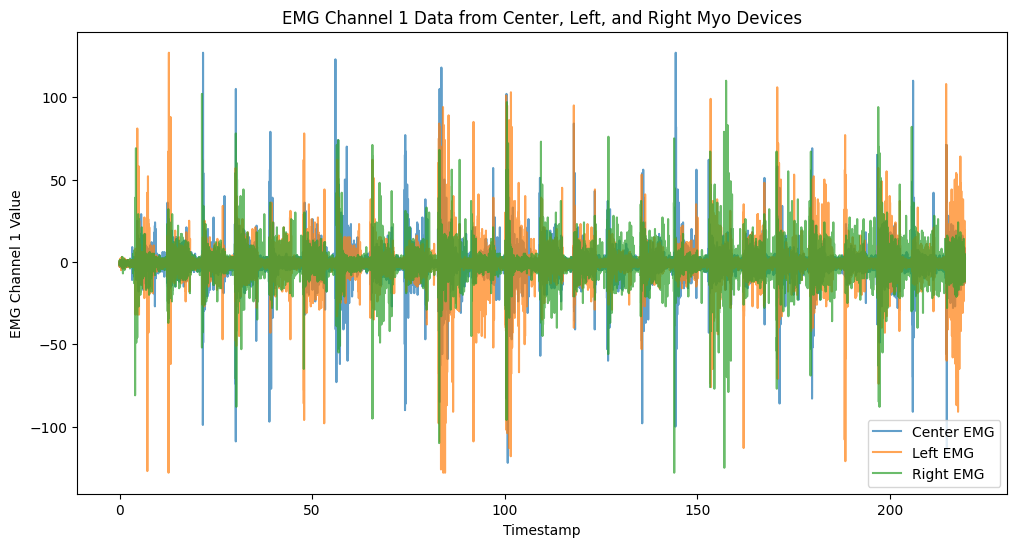

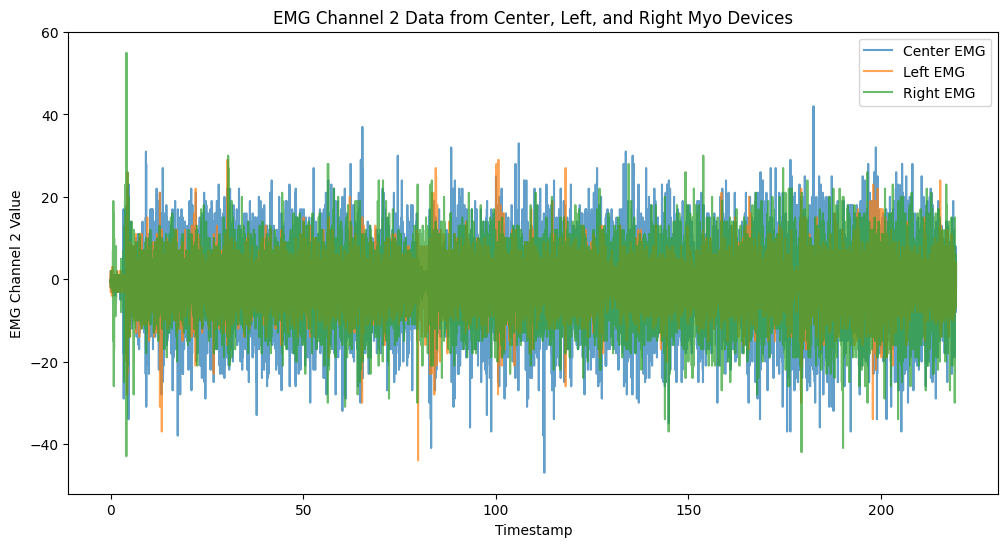

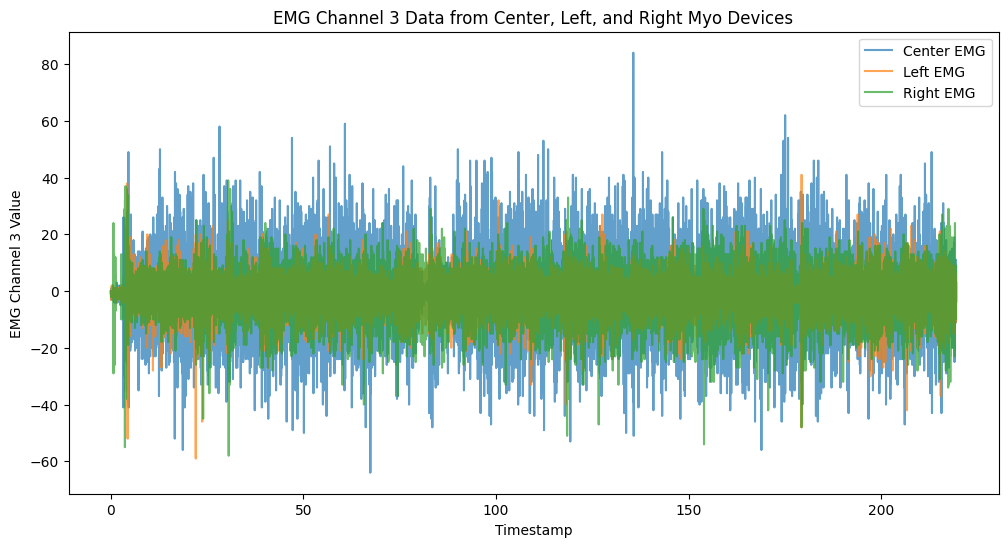

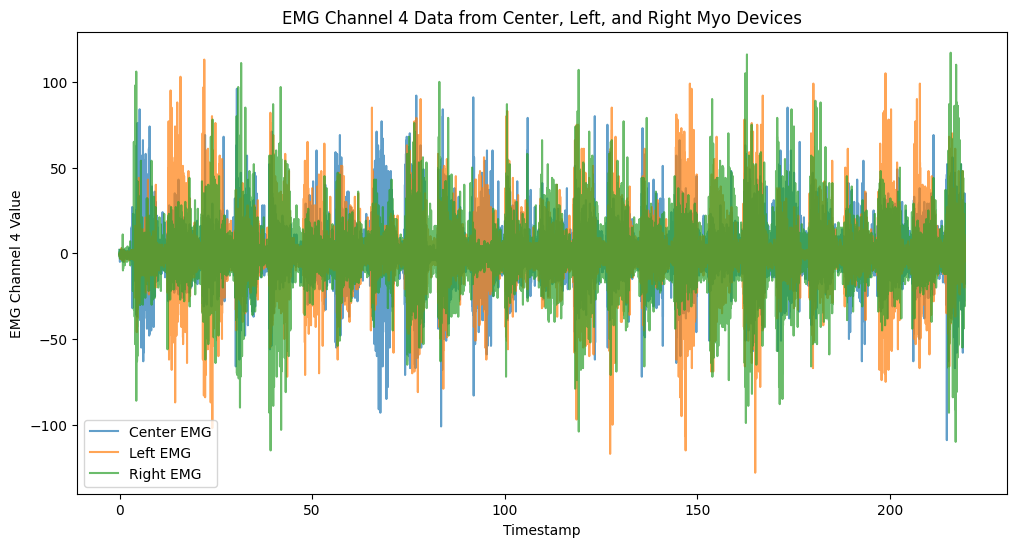

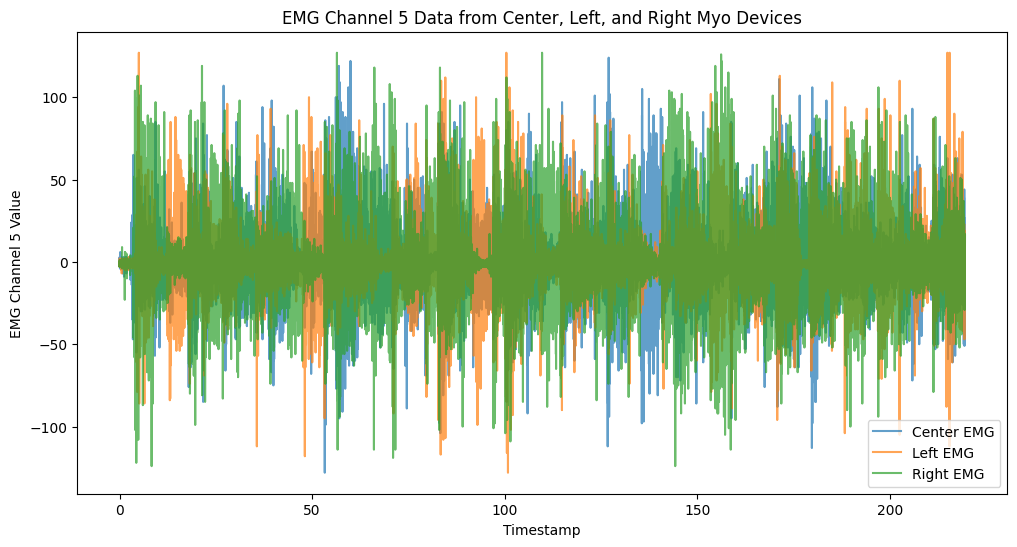

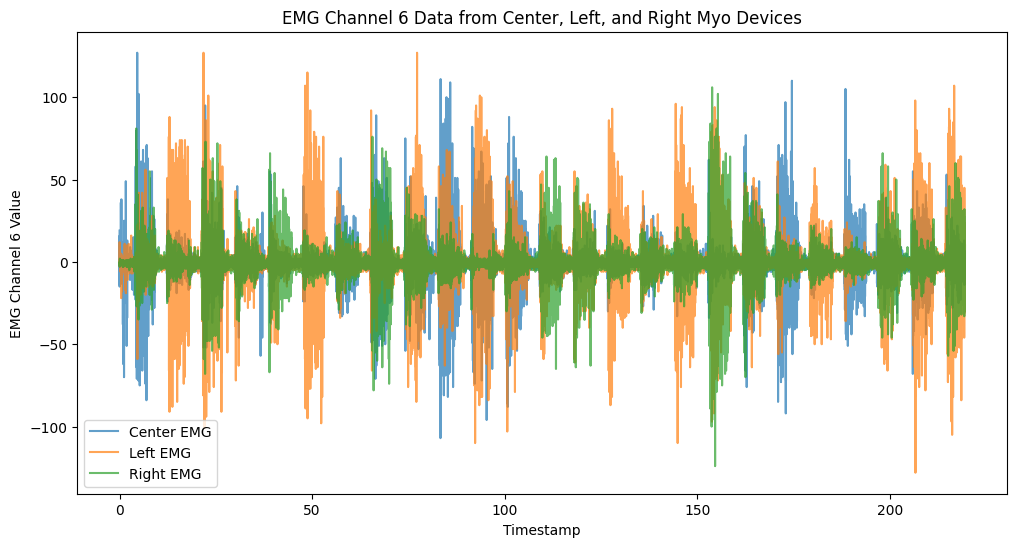

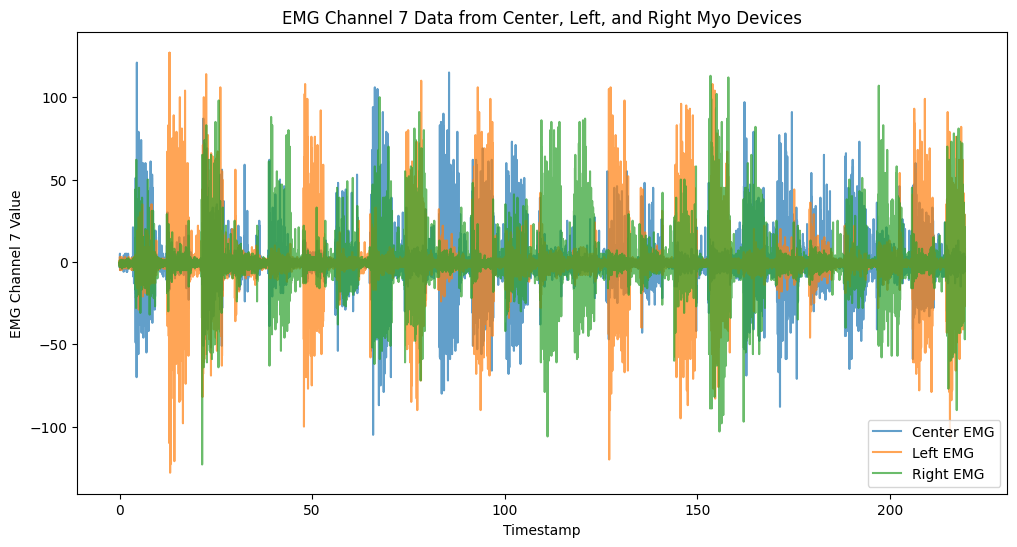

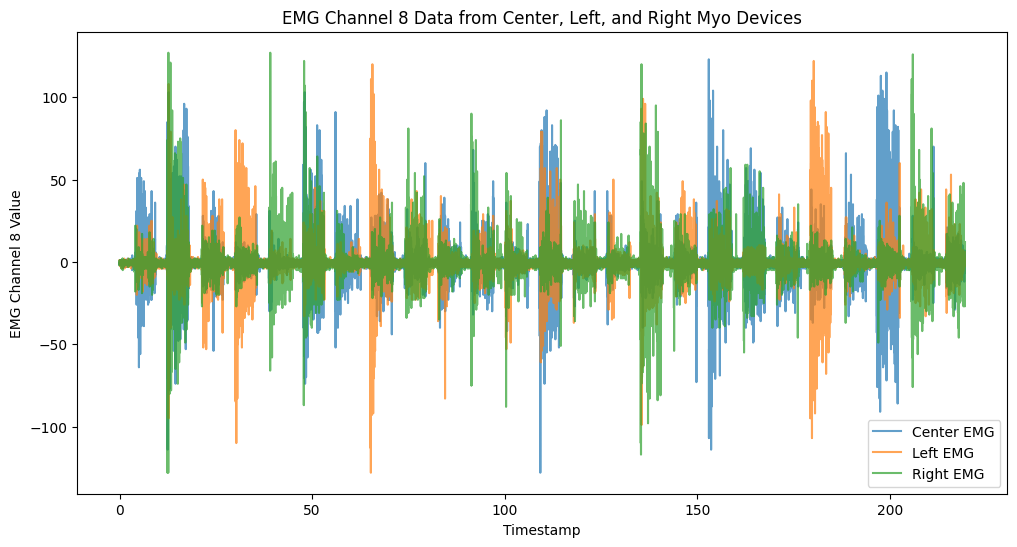

In [7]:
for i in range(1, 9):
    plt.figure(figsize=(12, 6))
    plt.plot(center_data['Timestamp']-center_data['Timestamp'][0], center_data[f'CH_{i}'], label='Center EMG', alpha=0.7)
    plt.plot(left_data['Timestamp']-left_data['Timestamp'][0], left_data[f'CH_{i}'], label='Left EMG', alpha=0.7)
    plt.plot(right_data['Timestamp']-right_data['Timestamp'][0], right_data[f'CH_{i}'], label='Right EMG', alpha=0.7)
    plt.xlabel('Timestamp')
    plt.ylabel(f'EMG Channel {i} Value')
    plt.title(f'EMG Channel {i} Data from Center, Left, and Right Myo Devices')
    plt.legend()
    plt.show()

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
import pickle
import os

# ----------------------------------------------
# MATH FUNCTIONS
# ----------------------------------------------

def zero_crossings(x):
    return ((x[:-1] * x[1:]) < 0).sum()

def slope_sign_changes(x):
    return np.sum((np.diff(np.sign(np.diff(x)))) != 0)

def waveform_length(x):
    return np.sum(np.abs(np.diff(x)))

# ----------------------------------------------
# SLIDING WINDOW EXTRACTOR
# ----------------------------------------------

def extract_sliding_features(df, sensor_cols, window_size=15, step_size=1):

    df['block_id'] = (df['State'] != df['State'].shift()).cumsum()

    all_features = []
    all_labels = []

    for block_id, group in df.groupby('block_id'):

        label = group['State'].iloc[0]
        data = group[sensor_cols].values
        L = len(data)

        if L < window_size:
            continue

        for i in range(0, L - window_size + 1, step_size):
            window = data[i:i+window_size]
            row = []

            # 72 features
            for ch in range(window.shape[1]):
                x = window[:, ch]

                feats = [
                    np.sqrt(np.mean(x**2)),
                    np.mean(np.abs(x)),
                    zero_crossings(x),
                    slope_sign_changes(x),
                    waveform_length(x),
                    np.var(x),
                    np.mean(x),
                    kurtosis(x) if np.std(x) > 0 else 0,
                    skew(x) if np.std(x) > 0 else 0
                ]

                row.extend(feats)

            all_features.append(row)
            all_labels.append(label)

    # DataFrame 72 features
    feat_suffixes = ['RMS','MAV','ZC','SSC','WL','VAR','MEAN','KURT','SKEW']
    col_names = [f"{ch}_{f}" for ch in sensor_cols for f in feat_suffixes]

    X_df = pd.DataFrame(all_features, columns=col_names)
    return X_df, all_labels


# ----------------------------------------------
# MAIN
# ----------------------------------------------

# Load your 3 datasets
datasets = [center_data, left_data, right_data]
sensor_cols = [f"CH_{i}" for i in range(1,9)]

all_X = []
all_y = []

print("\nExtracting features...")
for df in datasets:
    Xf, yf = extract_sliding_features(df, sensor_cols, 15, 1)
    all_X.append(Xf)
    all_y.extend(yf)

final_X = pd.concat(all_X, ignore_index=True)
label_encoder = LabelEncoder()
final_y = label_encoder.fit_transform(all_y)

print("\nSelecting BEST 10 features...")
selector = SelectKBest(score_func=f_classif, k=10)
X10 = selector.fit_transform(final_X, final_y)
best_cols = final_X.columns[selector.get_support()]

print("\nTop 10 features:", best_cols.tolist())

# Save dataset + selected columns
os.makedirs("processed", exist_ok=True)

np.save("processed/X_10features.npy", X10)
np.save("processed/y.npy", final_y)

with open("processed/selected_features.pkl", "wb") as f:
    pickle.dump(best_cols.tolist(), f)

print("\nSaved:")
print("  processed/X_10features.npy")
print("  processed/y.npy")
print("  processed/selected_features.pkl")


Extracting features...

Selecting BEST 10 features...

Top 10 features: ['CH_6_RMS', 'CH_6_MAV', 'CH_6_WL', 'CH_7_RMS', 'CH_7_MAV', 'CH_7_WL', 'CH_7_VAR', 'CH_8_RMS', 'CH_8_MAV', 'CH_8_WL']

Saved:
  processed/X_10features.npy
  processed/y.npy
  processed/selected_features.pkl


In [10]:
for i, cls in enumerate(label_encoder.classes_):
    print(i, cls)

0 LATERAL
1 OPEN
2 POINTER
3 POWER
4 REST
5 TRIPOD


In [11]:
final_X

,CH_1_RMS,CH_1_MAV,CH_1_ZC,CH_1_SSC,CH_1_WL,CH_1_VAR,CH_1_MEAN,CH_1_KURT,CH_1_SKEW,CH_2_RMS,...,CH_7_SKEW,CH_8_RMS,CH_8_MAV,CH_8_ZC,CH_8_SSC,CH_8_WL,CH_8_VAR,CH_8_MEAN,CH_8_KURT,CH_8_SKEW
0,1.390444,1.000000,0,8,17,0.933333,-1.000000,-0.091837,-0.887227,1.612452,...,1.136073,1.341641,1.133333,2,8,13,1.048889,-0.866667,-0.926027,0.476072
1,1.591645,1.200000,0,8,17,1.093333,-1.200000,-0.757585,-0.643797,1.549193,...,1.160460,1.316561,1.066667,2,8,14,1.093333,-0.800000,-1.159131,0.293907
2,1.591645,1.200000,0,8,16,1.093333,-1.200000,-0.757585,-0.643797,1.549193,...,0.930823,1.211060,0.933333,2,9,12,1.022222,-0.666667,-1.142722,0.071672
3,1.612452,1.266667,0,8,16,0.995556,-1.266667,-0.636878,-0.655625,1.549193,...,0.976242,1.238278,1.000000,2,9,12,0.995556,-0.733333,-1.013552,0.252944
4,1.673320,1.333333,0,8,15,1.022222,-1.333333,-0.887524,-0.458699,1.612452,...,0.871647,1.238278,1.000000,1,9,10,0.782222,-0.866667,-0.712035,0.315216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38188,3.540245,3.066667,8,10,68,10.755556,-1.333333,-0.913565,0.443938,2.529822,...,-0.206085,12.143585,8.533333,5,11,141,141.706667,-2.400000,2.839800,1.177147
38189,4.524010,3.533333,8,11,78,17.226667,-1.800000,0.367477,-0.527893,3.011091,...,-0.405814,11.304866,8.200000,4,12,130,87.688889,-6.333333,0.916276,-0.761147
38190,4.524010,3.533333,7,11,80,17.226667,-1.800000,0.367477,-0.527893,3.055050,...,-0.315656,11.337254,8.266667,4,12,147,87.573333,-6.400000,0.905158,-0.741471
38191,4.611580,3.666667,7,10,80,18.488889,-1.666667,0.153488,-0.450222,3.055050,...,-0.552245,11.099550,7.733333,4,11,152,88.782222,-5.866667,0.986894,-0.882418


In [12]:
X_selected = np.load("processed/X_10features.npy")
y = np.load("processed/y.npy")

with open("processed/selected_features.pkl", "rb") as f:
    cols = pickle.load(f)

print("X_selected shape:", X_selected.shape)
print("y shape:", y.shape)
print("Selected columns:", cols)

X_selected shape: (38193, 10)
y shape: (38193,)
Selected columns: ['CH_6_RMS', 'CH_6_MAV', 'CH_6_WL', 'CH_7_RMS', 'CH_7_MAV', 'CH_7_WL', 'CH_7_VAR', 'CH_8_RMS', 'CH_8_MAV', 'CH_8_WL']


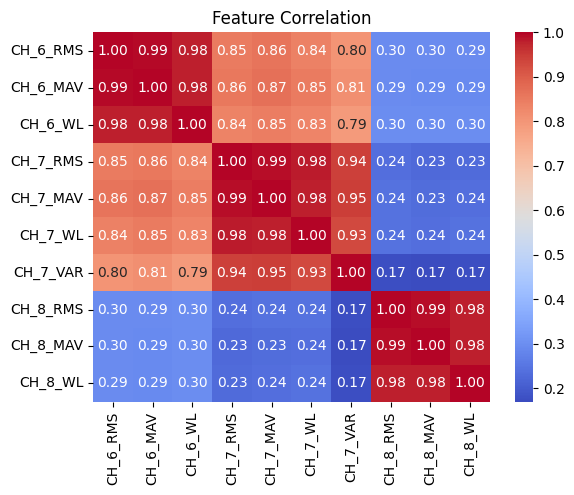

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = pd.DataFrame(X_selected, columns=cols).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ----------- USE AS 10 FEATURES SELECIONADAS -----------
X = X_selected              # agora é (N amostras, 10 features)
y = final_y                 # rótulos
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

average=np.array([0])
preci=np.array([0])
senci=np.array([0])
bst_est=[]

kf = KFold(n_splits=5, shuffle=True, random_state=7)

def training_and_testing(estimator, param_grid, X_train, y_train, X_test, y_test):
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=kf,
        scoring='accuracy',
        verbose=2
    )

    # Perform the grid search
    grid_search.fit(X_train, y_train)

    # Best parameters and best score
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    sensitivity = recall_score(y_test, y_pred, average='weighted')

    print(f"Final Test Accuracy: {accuracy:.2f}")
    print(f"Final Test Precision: {precision:.2f}")
    print(f"Final Test Sensitivity (Recall): {sensitivity:.2f}")

    # Confusion matrix
    print("\nFinal Confusion Matrix (on test data):")
    mat_con = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=mat_con)
    disp.plot()
    plt.show()

    return accuracy, precision, sensitivity, grid_search


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=2; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=4; total time=   0.0s
[CV] END ....................metric=minkowski, n_neighbors=6; total time=   0.0s
[CV] END ....................metric=minkowski, n

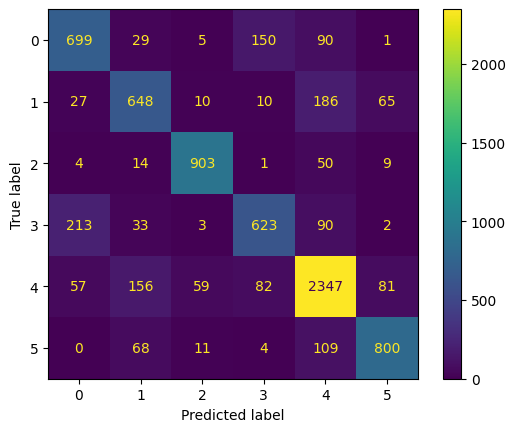

Accuracy:  0.7880612645634245
Precision:  0.7872108890170201
Sensitivity:  0.7880612645634245
✔ Saved best KNN model → db/knn_model_10_features.joblib


In [8]:
from sklearn.neighbors import KNeighborsClassifier
import joblib
# Define the model and parameters to tune
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [2, 4, 6, 8],  # You can extend this list based on your dataset
    #'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'chebyshev', 'euclidean', 'manhattan']
}

accuracy, precision, sensitivity, grid_search = training_and_testing(knn, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST KNN MODEL ---
best_knn = grid_search.best_estimator_
joblib.dump(best_knn, "db/knn_model_10_features.joblib")
print("✔ Saved best KNN model → db/knn_model_10_features.joblib")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ..................................var_smoothing=1.0; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ...................var_smoothing=0.8111308307896871; total time=   0.0s
[CV] END ....................var_smoothing=0.657933224657568; total time=   0.0s
[CV] END ....................var_smoothing=0.6

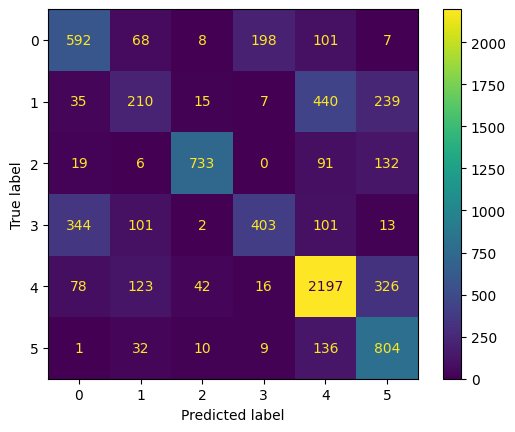

Accuracy:  0.6465505956277
Precision:  0.6449299802484325
Sensitivity:  0.6465505956277
✔ Saved best GaussianNB model → db/gnb_model_10_features.joblib


In [9]:
from sklearn.naive_bayes import GaussianNB
import joblib
# Define the model and parameters to tune
gnb = GaussianNB()
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
}

accuracy, precision, sensitivity, grid_search = training_and_testing(gnb, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST GAUSSIANNB MODEL ---
best_gnb = grid_search.best_estimator_
joblib.dump(best_gnb, "db/gnb_model_10_features.joblib")
print("✔ Saved best GaussianNB model → db/gnb_model_10_features.joblib")

In [10]:
# from sklearn.linear_model import LogisticRegression
# # Define the model and parameters to tune
# log_reg = LogisticRegression(max_iter=10000)  # Increasing max_iter for convergence with larger datasets or more complex models
# param_grid = {
#     'C': np.logspace(-4, 4, 20),  # Explore a range of regularization strengths
#     'penalty': ['l1', 'l2']#,  # 'l1', 'l2', 'elasticnet' might be options, depending on the solver
#     #'solver': ['lbfgs', 'liblinear']  # Suitable solvers for small to medium datasets
# }

# accuracy, precision, sensitivity, grid_search = training_and_testing(log_reg, param_grid, X_train, y_train, X_test, y_test)
# print("Accuracy: ", accuracy)
# print("Precision: ", precision)
# print("Sensitivity: ", sensitivity)
# average = np.vstack((average,accuracy))
# preci=np.vstack((preci,precision))
# senci=np.vstack((senci,sensitivity))
# bst_est.append(grid_search.best_params_) 

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=4; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=6; total time=   0.0s
[CV] END max_depth=5, min_samples_le

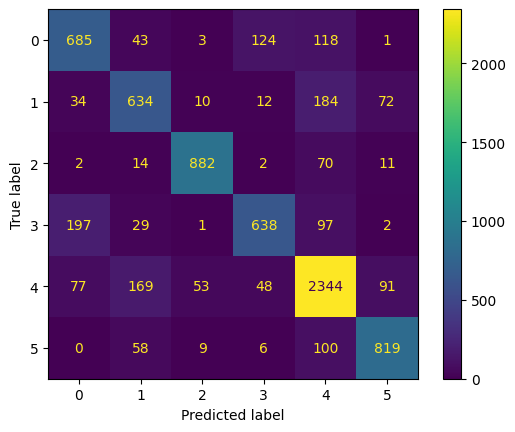

Accuracy:  0.7857049352009425
Precision:  0.7857507849443043
Sensitivity:  0.7857049352009425
✔ Saved best Decision Tree model → db/decision_tree_10_features_model.joblib


In [11]:
from sklearn.tree import DecisionTreeClassifier
import joblib
# Define the model and parameters to tune
decision_tree = DecisionTreeClassifier()
param_grid = {
    'max_depth': [5, 10, 15, 20, 25, 30],  # None means no limit
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [2, 4, 6, 8]
}

accuracy, precision, sensitivity, grid_search = training_and_testing(decision_tree, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST DECISION TREE MODEL ---
best_dt = grid_search.best_estimator_
joblib.dump(best_dt, "db/decision_tree_10_features_model.joblib")
print("✔ Saved best Decision Tree model → db/decision_tree_10_features_model.joblib")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   2.9s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   2.9s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   3.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   2.8s
[CV] END max_depth=5, min_samples_lea

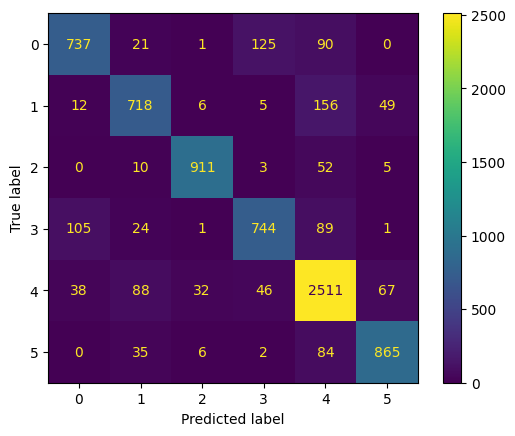

Accuracy:  0.8490640136143475
Precision:  0.8488028055727765
Sensitivity:  0.8490640136143475
✔ Saved best Random Forest model → db/random_forest_model_10_features.joblib


In [12]:
from sklearn.ensemble import RandomForestClassifier
import joblib
# Define the model and parameters to tune
random_forest = RandomForestClassifier()
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [5, 10, 15, 20],  # Maximum depth of the tree
    'min_samples_split': [2, 4, 6, 8],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2, 4, 6, 8]  # Minimum number of samples required at each leaf node
}

accuracy, precision, sensitivity, grid_search = training_and_testing(random_forest, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST RANDOM FOREST MODEL ---
best_rf = grid_search.best_estimator_
joblib.dump(best_rf, "db/random_forest_model_10_features.joblib")
print("✔ Saved best Random Forest model → db/random_forest_model_10_features.joblib")

c:\Users\gusta\Documents\GitHub\Reco-Myo-Rush\Assets\Scripts\myo\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=50. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.696 total time=  11.4s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.695 total time=  12.0s
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.693 total time=  11.5s
[CV 4/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.689 total time=  11.4s
[CV 5/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.692 total time=  11.8s
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.369 total time=  57.7s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.373 total time=  57.4s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.364 total time=  58.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.362 total time=  58.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.353 total time=  58.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.369 total time=  46.7s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;

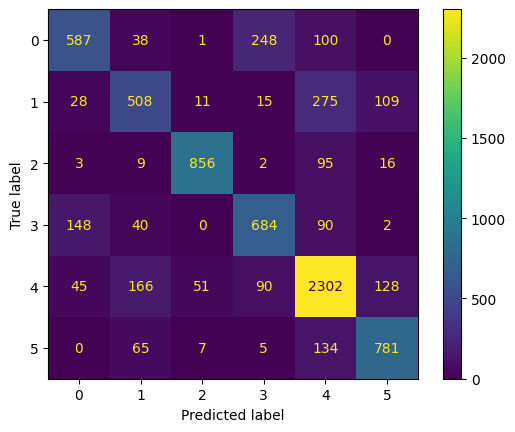

Accuracy:  0.7485272941484488
Precision:  0.7475599652991759
Sensitivity:  0.7485272941484488


In [13]:
from sklearn.model_selection import RandomizedSearchCV # Assuming you use KFold
def training_and_testing_svm(estimator, param_grid, X_train, y_train, X_test, y_test):
    grid_search = RandomizedSearchCV(estimator=estimator, param_distributions=param_grid, cv=kf, scoring='accuracy', verbose=3, n_iter=50)  # n_iter can be adjusted based on the number of combinations you want to try

    # Perform the grid search
    grid_search.fit(X_train, y_train)

    # Best parameters and best score
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Calculate and print all final metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    sensitivity = recall_score(y_test, y_pred, average='weighted') # Sensitivity is the same as recall

    print(f"Final Test Accuracy: {accuracy:.2f}")
    print(f"Final Test Precision: {precision:.2f}")
    print(f"Final Test Sensitivity (Recall): {sensitivity:.2f}")

    # Display the final confusion matrix
    print("\nFinal Confusion Matrix (on test data):")
    mat_con = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=mat_con)
    disp.plot()
    plt.show()
    return accuracy, precision, sensitivity, grid_search

from sklearn.svm import SVC
from sklearn.datasets import make_classification # Import make_classification
from sklearn.model_selection import train_test_split # Import train_test_split

from sklearn.svm import SVC
# Define the model and parameters to tune
svm = SVC()
param_grid = [
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 1, 0.1, 0.01]},
    #{'kernel': ['linear'], 'C': [0.1, 1, 10, 100]}
]

accuracy, precision, sensitivity, grid_search = training_and_testing_svm(svm, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END .........................shrinkage=None, solver=svd; total time=   0.0s
[CV] END .........................shrinkage=None, solver=svd; total time=   0.0s
[CV] END .........................shrinkage=None, solver=svd; total time=   0.0s
[CV] END .........................shrinkage=None, solver=svd; total time=   0.0s
[CV] END .........................shrinkage=None, solver=svd; total time=   0.0s
[CV] END ........................shrinkage=None, solver=lsqr; total time=   0.0s
[CV] END ........................shrinkage=None, solver=lsqr; total time=   0.0s
[CV] END ........................shrinkage=None, solver=lsqr; total time=   0.0s
[CV] END ........................shrinkage=None, solver=lsqr; total time=   0.0s
[CV] END ........................shrinkage=None, solver=lsqr; total time=   0.0s
[CV] END .......................shrinkage=None, solver=eigen; total time=   0.0s
[CV] END .......................shrinkage=None, 

c:\Users\gusta\Documents\GitHub\Reco-Myo-Rush\Assets\Scripts\myo\venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 75.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\gusta\Documents\GitHub\Reco-Myo-Rush\Assets\Scripts\myo\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\gusta\Documents\GitHub\Reco-Myo-Rush\Assets\Scripts\myo\venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *

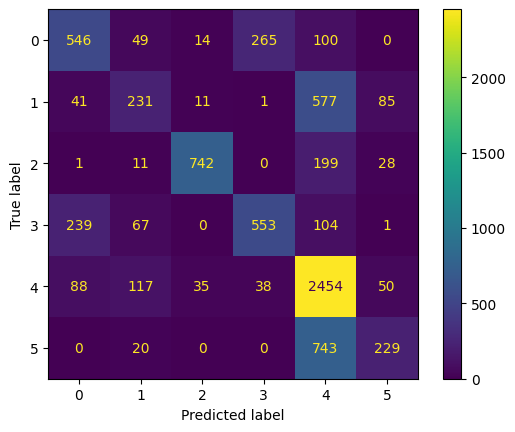

Accuracy:  0.6224636732556618
Precision:  0.6237459081467411
Sensitivity:  0.6224636732556618
✔ Saved best LDA model → db/lda_model_10_features.joblib


In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import joblib

lda = LinearDiscriminantAnalysis()
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.1, 0.5, 0.9]
}

accuracy, precision, sensitivity, grid_search = training_and_testing(lda, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST LDA MODEL ---
best_lda = grid_search.best_estimator_
joblib.dump(best_lda, "db/lda_model_10_features.joblib")
print("✔ Saved best LDA model → db/lda_model_10_features.joblib")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END activation=tanh  , alpha=0.0001, hidden_layer_sizes=(50,), solver=adam; total time=   0.0s
[CV] END activation=tanh  , alpha=0.0001, hidden_layer_sizes=(50,), solver=adam; total time=   0.0s
[CV] END activation=tanh  , alpha=0.0001, hidden_layer_sizes=(50,), solver=adam; total time=   0.0s
[CV] END activation=tanh  , alpha=0.0001, hidden_layer_sizes=(50,), solver=adam; total time=   0.0s
[CV] END activation=tanh  , alpha=0.0001, hidden_layer_sizes=(50,), solver=adam; total time=   0.0s
[CV] END activation=tanh  , alpha=0.0001, hidden_layer_sizes=(50,), solver=sgd; total time=   0.0s
[CV] END activation=tanh  , alpha=0.0001, hidden_layer_sizes=(50,), solver=sgd; total time=   0.0s
[CV] END activation=tanh  , alpha=0.0001, hidden_layer_sizes=(50,), solver=sgd; total time=   0.0s
[CV] END activation=tanh  , alpha=0.0001, hidden_layer_sizes=(50,), solver=sgd; total time=   0.0s
[CV] END activation=tanh  , alpha=0.0001, 

c:\Users\gusta\Documents\GitHub\Reco-Myo-Rush\Assets\Scripts\myo\venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
200 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\gusta\Documents\GitHub\Reco-Myo-Rush\Assets\Scripts\myo\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\gusta\Documents\GitHub\Reco-Myo-Rush\Assets\Scripts\myo\venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params(

Best parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'solver': 'adam'}
Best cross-validation score: 0.77
Final Test Accuracy: 0.77
Final Test Precision: 0.77
Final Test Sensitivity (Recall): 0.77

Final Confusion Matrix (on test data):


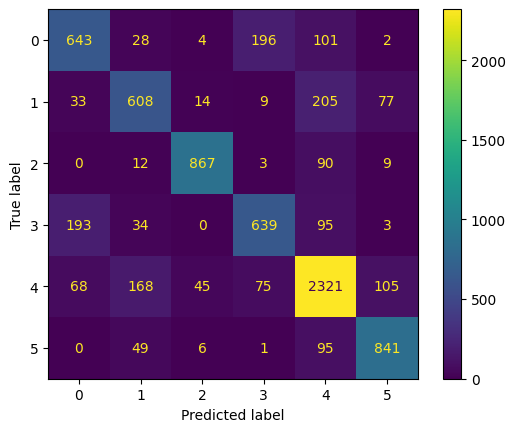

Accuracy:  0.7748396386961645
Precision:  0.7736545945229967
Sensitivity:  0.7748396386961645
✔ Saved best MLP model → db/mlp_model_10_features.joblib


In [15]:
from sklearn.neural_network import MLPClassifier
import joblib

mlp = MLPClassifier(max_iter=1000)  # Increased max_iter for better convergence
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
              'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
              'activation': ['tanh  ', 'relu'],
              'solver': ['adam', 'sgd']}

accuracy, precision, sensitivity, grid_search = training_and_testing(mlp, param_grid, X_train, y_train, X_test, y_test)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Sensitivity: ", sensitivity)
average = np.vstack((average,accuracy))
preci=np.vstack((preci,precision))
senci=np.vstack((senci,sensitivity))
bst_est.append(grid_search.best_params_)

# --- SAVE BEST MLP MODEL ---
best_mlp = grid_search.best_estimator_
joblib.dump(best_mlp, "db/mlp_model_10_features.joblib")
print("✔ Saved best MLP model → db/mlp_model_10_features.joblib")

In [16]:
# prompt: take  average preci and sensci  and consider this, rows are porcentages so must be *100 and it must be first column value +/- second column value, storage them as csv
import pandas as pd
def create_df(average, preci, senci, bst_est):
    # Convert numpy arrays to DataFrames
    average_df = pd.DataFrame(average, columns=['Accuracy'])
    preci_df = pd.DataFrame(preci, columns=['Precision'])
    senci_df = pd.DataFrame(senci, columns=['Sensitivity'])

    # Multiply the columns by 100 for percentage
    average_df[['Accuracy']] *= 100
    preci_df[['Precision']] *= 100
    senci_df[['Sensitivity']] *= 100

    # Combine mean and std columns into a single string format for each metric
    average_df['Accuracy'] = average_df['Accuracy'].round(2).astype(str) 
    preci_df['Precision'] = preci_df['Precision'].round(2).astype(str)
    senci_df['Sensitivity'] = senci_df['Sensitivity'].round(2).astype(str)

    results_df = pd.DataFrame({
    'Model': ['KNN', 'GaussianNB', 'Decision Tree', 'Random Forest', 'SVM', 'LDA', 'MLP'],
    'Accuracy': average_df['Accuracy'].iloc[1:].values,
    'Precision': preci_df['Precision'].iloc[1:].values,
    'Sensitivity': senci_df['Sensitivity'].iloc[1:].values,
    'Best Estimator Params': bst_est
    })
    return results_df

results_df = create_df(average, preci, senci, bst_est)
# Save the results to a CSV file
results_df.to_csv('model_performance_summary_force_hybrid.csv', index=False)

print("\nModel Performance Summary:")
results_df


Model Performance Summary:


,Model,Accuracy,Precision,Sensitivity,Best Estimator Params
0,KNN,78.81,78.72,78.81,"{'metric': 'manhattan', 'n_neighbors': 6}"
1,GaussianNB,64.66,64.49,64.66,{'var_smoothing': 0.01519911082952933}
2,Decision Tree,78.57,78.58,78.57,"{'max_depth': 15, 'min_samples_leaf': 2, 'min_..."
3,Random Forest,84.91,84.88,84.91,"{'max_depth': 20, 'min_samples_leaf': 2, 'min_..."
4,SVM,74.85,74.76,74.85,"{'kernel': 'rbf', 'gamma': 'scale', 'C': 100}"
5,LDA,62.25,62.37,62.25,"{'shrinkage': 'auto', 'solver': 'lsqr'}"
6,MLP,77.48,77.37,77.48,"{'activation': 'relu', 'alpha': 0.01, 'hidden_..."
